In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from pathlib import Path
from MITRotor import IEA10MW
from wrf_io import postproc

In [3]:
rotor = IEA10MW()

nElements = 26
nSections = 158

In [5]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [6]:
# file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/total/10MW/gad_sweep/*/input_sounding")
file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/*/input_sounding")



data = extract_columns(file_list)

t = np.linspace(0,2*np.pi,158)
r = np.linspace(0,1,26)

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * rotor.R + 378

In [7]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [8]:
casenames = [r's0_v4', r'sn2_v2', r's0_v2',r's2_v2', r'sn4_v0', r'sn2_v0', r's0_v0', r's2_v0', r's4_v0', r'sn2_vn2', r's0_vn2', r's2_vn2', r's0_vn4']
# casenames = [r's000000_v000000']

wrfles_bem = []
for count, name in enumerate(casenames):
    # wrfles_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/total/10MW/gad_sweep/'+casenames[count]+'/'+casenames[count]+'_lite.npz')))
    wrfles_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/'+casenames[count]+'_new.npz')))


In [8]:
wrfles_bem[0]['bpz'] - wrfles_bem[0]['hub_height']

array([[[ 4.26730347,  4.26391602,  4.2538147 , ...,  4.23696899,
          4.2538147 ,  4.26391602],
        [ 8.00192261,  7.99560547,  7.97662354, ...,  7.94503784,
          7.97662354,  7.99560547],
        [11.73654175, 11.7272644 , 11.69943237, ..., 11.65310669,
         11.69943237, 11.7272644 ],
        ...,
        [90.16351318, 90.09222412, 89.878479  , ..., 89.52264404,
         89.878479  , 90.09222412],
        [93.89813232, 93.82391357, 93.60131836, ..., 93.23071289,
         93.60131836, 93.82391357],
        [97.63275146, 97.55557251, 97.3241272 , ..., 96.93878174,
         97.32409668, 97.55557251]],

       [[ 4.26730347,  4.26391602,  4.2538147 , ...,  4.23696899,
          4.2538147 ,  4.26391602],
        [ 8.00192261,  7.99560547,  7.97662354, ...,  7.94503784,
          7.97662354,  7.99560547],
        [11.73654175, 11.7272644 , 11.69943237, ..., 11.65310669,
         11.69943237, 11.7272644 ],
        ...,
        [90.16351318, 90.09222412, 89.878479  , ..., 8

In [9]:
wrfles_bem[0]['bpy'] - wrfles_bem[0]['tower_yloc']

array([[[ 0.        , -0.16967773, -0.33905029, ...,  0.50787354,
          0.33905029,  0.16967773],
        [ 0.        , -0.31811523, -0.63574219, ...,  0.95239258,
          0.63574219,  0.31811523],
        [ 0.        , -0.46661377, -0.93249512, ...,  1.39685059,
          0.93249512,  0.46661377],
        ...,
        [ 0.        , -3.58459473, -7.16351318, ..., 10.73114014,
          7.16351318,  3.58459473],
        [ 0.        , -3.73303223, -7.46020508, ..., 11.17559814,
          7.46026611,  3.73309326],
        [ 0.        , -3.88153076, -7.75695801, ..., 11.62011719,
          7.75695801,  3.88153076]],

       [[ 0.        , -0.16967773, -0.33905029, ...,  0.50787354,
          0.33905029,  0.16967773],
        [ 0.        , -0.31811523, -0.63574219, ...,  0.95239258,
          0.63574219,  0.31811523],
        [ 0.        , -0.46661377, -0.93249512, ...,  1.39685059,
          0.93249512,  0.46661377],
        ...,
        [ 0.        , -3.58459473, -7.16351318, ..., 1

In [16]:
xs = [0,1,1,1,2,2,2,2,2,3,3,3,4]
ys = [2,1,2,3,0,1,2,3,4,1,2,3,2]

fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(20, 15), constrained_layout=True,sharex=True, sharey=True)

ind = np.zeros((nElements, nSections, len(xs)))
ct  = np.zeros((nElements, nSections, len(xs)))

T = np.zeros_like(xs)
P = np.zeros_like(xs)

alpha_coeff = 3

h = np.sqrt(wrfles_bem[0]['dx']**2 + wrfles_bem[0]['dy']**2 + wrfles_bem[0]['dx']**2)

delta = alpha_coeff * h
r_vec = wrfles_bem[count]['rOverR']
theta_vec = np.linspace(0, 2*np.pi, nSections)

radius = wrfles_bem[count]['diameter']/2


for count,case in enumerate(casenames):
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Get radial points
    a = ((wrfles_bem[count]['rOverR'] * rotor.R) - rotor.hub_radius)/rotor.R
    r = (rotor.hub_radius + a * (rotor.R - rotor.hub_radius)) / rotor.R

    # Compute induction
    ind[:,:,count] = 1 - np.mean(wrfles_bem[count]['u'],axis=0) / u_inf.T

    # SHAPIRO CORRECTION ------------------
    # M = shapiro_correction(ind[:,:,count], r_vec, theta_vec, delta, radius)
    # print(M)
    # ind = 1 - np.mean(wrfles_bem[count]['u'] * M,axis=0) / u_inf.T
    # -------------------------------------

    phi = np.deg2rad(np.mean(wrfles_bem[count]['phi'], axis=0))
    Cl = np.mean(wrfles_bem[count]['cl'], axis=0)
    Cd = np.mean(wrfles_bem[count]['cd'], axis=0)

    r =  (np.ones_like(Cd.T) * r).T

    # Solidity
    sigma = rotor.solidity_func(r)
    # sigma = 3/nSections
    # chord = rotor.chord_func(r)
    chord = np.array([4.649046,4.844576,5.216862,5.647547,5.931514,5.96353,5.812206,5.569981,5.273268,4.94348,4.598646,4.251929,3.911027,3.581805,3.269938,2.978544,2.70897,2.462014,2.237137,2.035348,1.855479,1.691271,1.526768,1.308778,0.7955106,0.5734])
    chord =  (np.ones_like(Cd.T) * chord).T

    # Relative velocity
    W = np.mean(wrfles_bem[count]['vrel'], axis=0) / ((u_inf**2 + v_inf**2)**(1/2)).T

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    Ctan = Cl * np.sin(phi) - Cd * np.cos(phi)

    dT = 1/2 * 3 * 1.225 * chord * np.mean(wrfles_bem[count]['vrel'], axis=0)**2 * Cax

    dQ = 1/2 * 3 * 1.225 * chord * np.mean(wrfles_bem[count]['vrel'], axis=0)**2 * Ctan * r

    T[count] = 1/(2*np.pi) * np.trapezoid(np.trapezoid(dT,np.linspace(0, 2*np.pi, nSections)),np.linspace(0,1,26))

    P[count] = 1/(2*np.pi) * np.trapezoid(np.trapezoid(dT,np.linspace(0, 2*np.pi, nSections)),np.linspace(0,1,26)) * np.mean(wrfles_bem[count]['omega'])

    # Local CT
    # ct[:,:,count] = sigma * W**2 * Cax * M**2

    ct[:,:,count] = sigma * W**2 * Cax 

    mesh = ax[xs[count],ys[count]].scatter(ind[:,:,count], ct[:,:,count], cmap='viridis', s=10, edgecolor='none',color='#176d2e',alpha=0.25,zorder=1)

    ct_annular  = 1/(2 * np.pi) * np.trapezoid(ct[:,:,count], np.linspace(0, 2*np.pi, nSections), axis=-1)
    ind_annular = 1/(2 * np.pi) * np.trapezoid(ind[:,:,count], np.linspace(0, 2*np.pi, nSections), axis=-1)

    ct_rotor = 2 * np.trapezoid(ct_annular * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])
    ind_rotor = 2 * np.trapezoid(ind_annular * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])

    mesh = ax[xs[count],ys[count]].scatter(ind_rotor, ct_rotor, cmap='viridis', s=110, edgecolor='none',color='#ffc300',alpha=1,zorder=4)

    a_mom = np.linspace(0,0.75,50)
    ct_mom = 4 * a_mom * (1 - a_mom)
    ax[xs[count],ys[count]].plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=2)

    ct_mad = np.linspace(0,1.75,75)
    k1 = 0.2460
    k2 = 0.0586
    k3 = 0.0883
    a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
    ax[xs[count],ys[count]].plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=3)

    # ax[xs[count],ys[count]].set_aspect('equal')
    ax[xs[count],ys[count]].set_xlim([0,0.6])
    ax[xs[count],ys[count]].set_ylim([0,1.5])

    ax[4,4].scatter(ind[:,:,count], ct[:,:,count], cmap='viridis', s=10, edgecolor='none',color='#176d2e',zorder=3,alpha=0.05)

np.save("../rotor_coeffs/shapiro/10MW_local_averages_r.npy", [ind,ct])


ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,3].axis('off')
ax[0,4].axis('off')

ax[1,0].axis('off')
ax[1,4].axis('off')

ax[3,0].axis('off')
ax[3,4].axis('off')

ax[4,0].axis('off')
ax[4,1].axis('off')
ax[4,3].axis('off')
# ax[4,4].axis('off')
for spine in ax[4,4].spines.values():
    spine.set_linewidth(2.5)
    spine.set_edgecolor('red')

ax[4,4].plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1)
ax[4,4].plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2)
ax[4,4].set_title('Ensemble', fontweight='bold',color='r')

ax[2,0].set_ylabel('$C_T$ [-]', fontsize=20)
ax[4,2].set_xlabel('$a$ [-]', fontsize=20)

# Add the number line below the subplots
line_y = -0.04  # Y-position for the line (below the subplots)
line_x_start, line_x_end = -0.03, 1  # Start and end positions of the line (normalized coordinates)

# Draw the line
fig.lines.extend([
    plt.Line2D([line_x_start, line_x_end], [line_y, line_y], color="black", transform=fig.transFigure, linewidth=2)
])

# Add text to the number line
positions = np.linspace(line_x_start, line_x_end, 6)+0.14  # Adjust the number of points and spacing
labels = ['-0.4', '-0.2', '0.0', '0.2', '0.4']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(pos, line_y - 0.03, label, ha='center', fontsize=20)

# Add a title for the number line
fig.text(0.52, line_y - 0.075, 'Speed shear', ha='center', fontsize=25)

line_x = -0.03  # Y-position for the line (below the subplots)
line_y_start, line_y_end = -0.04, 1  # Start and end positions of the line (normalized coordinates)

# Draw the line
fig.lines.extend([
    plt.Line2D([line_x, line_x], [line_y_start, line_y_end], color="black", transform=fig.transFigure, linewidth=2)
])

# Add text to the number line
positions = np.linspace(line_y_start, line_y_end, 6)+0.15  # Adjust the number of points and spacing
labels = ['-0.4', '-0.2', '0.0', '0.2', '0.4']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(line_y - 0.01,pos, label, ha='center', fontsize=20)

# Add a title for the number line
fig.text(-0.075,0.46, 'Direction shear', ha='center', fontsize=25,rotation=90)
fig.text(-0.02,0.985, 'IEA 10MW', ha='left', fontsize=25,rotation=0)
fig.text(-0.02,0.96, 'Local (No averaging)', ha='left', fontsize=25,rotation=0)

# plt.savefig(f"./figs/wrf_10MW_local.png", bbox_inches="tight", dpi=600)
plt.show()

/tmp/ipykernel_666132/3625928976.py:77: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[xs[count],ys[count]].scatter(ind[:,:,count], ct[:,:,count], cmap='viridis', s=10, edgecolor='none',color='#176d2e',alpha=0.25,zorder=1)
/tmp/ipykernel_666132/3625928976.py:85: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[xs[count],ys[count]].scatter(ind_rotor, ct_rotor, cmap='viridis', s=110, edgecolor='none',color='#ffc300',alpha=1,zorder=4)
/tmp/ipykernel_666132/3625928976.py:102: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[4,4].scatter(ind[:,:,count], ct[:,:,count], cmap='viridis', s=10, edgecolor='none',color='#176d2e',zorder=3,alpha=0.05)


NameError: name 'power' is not defined

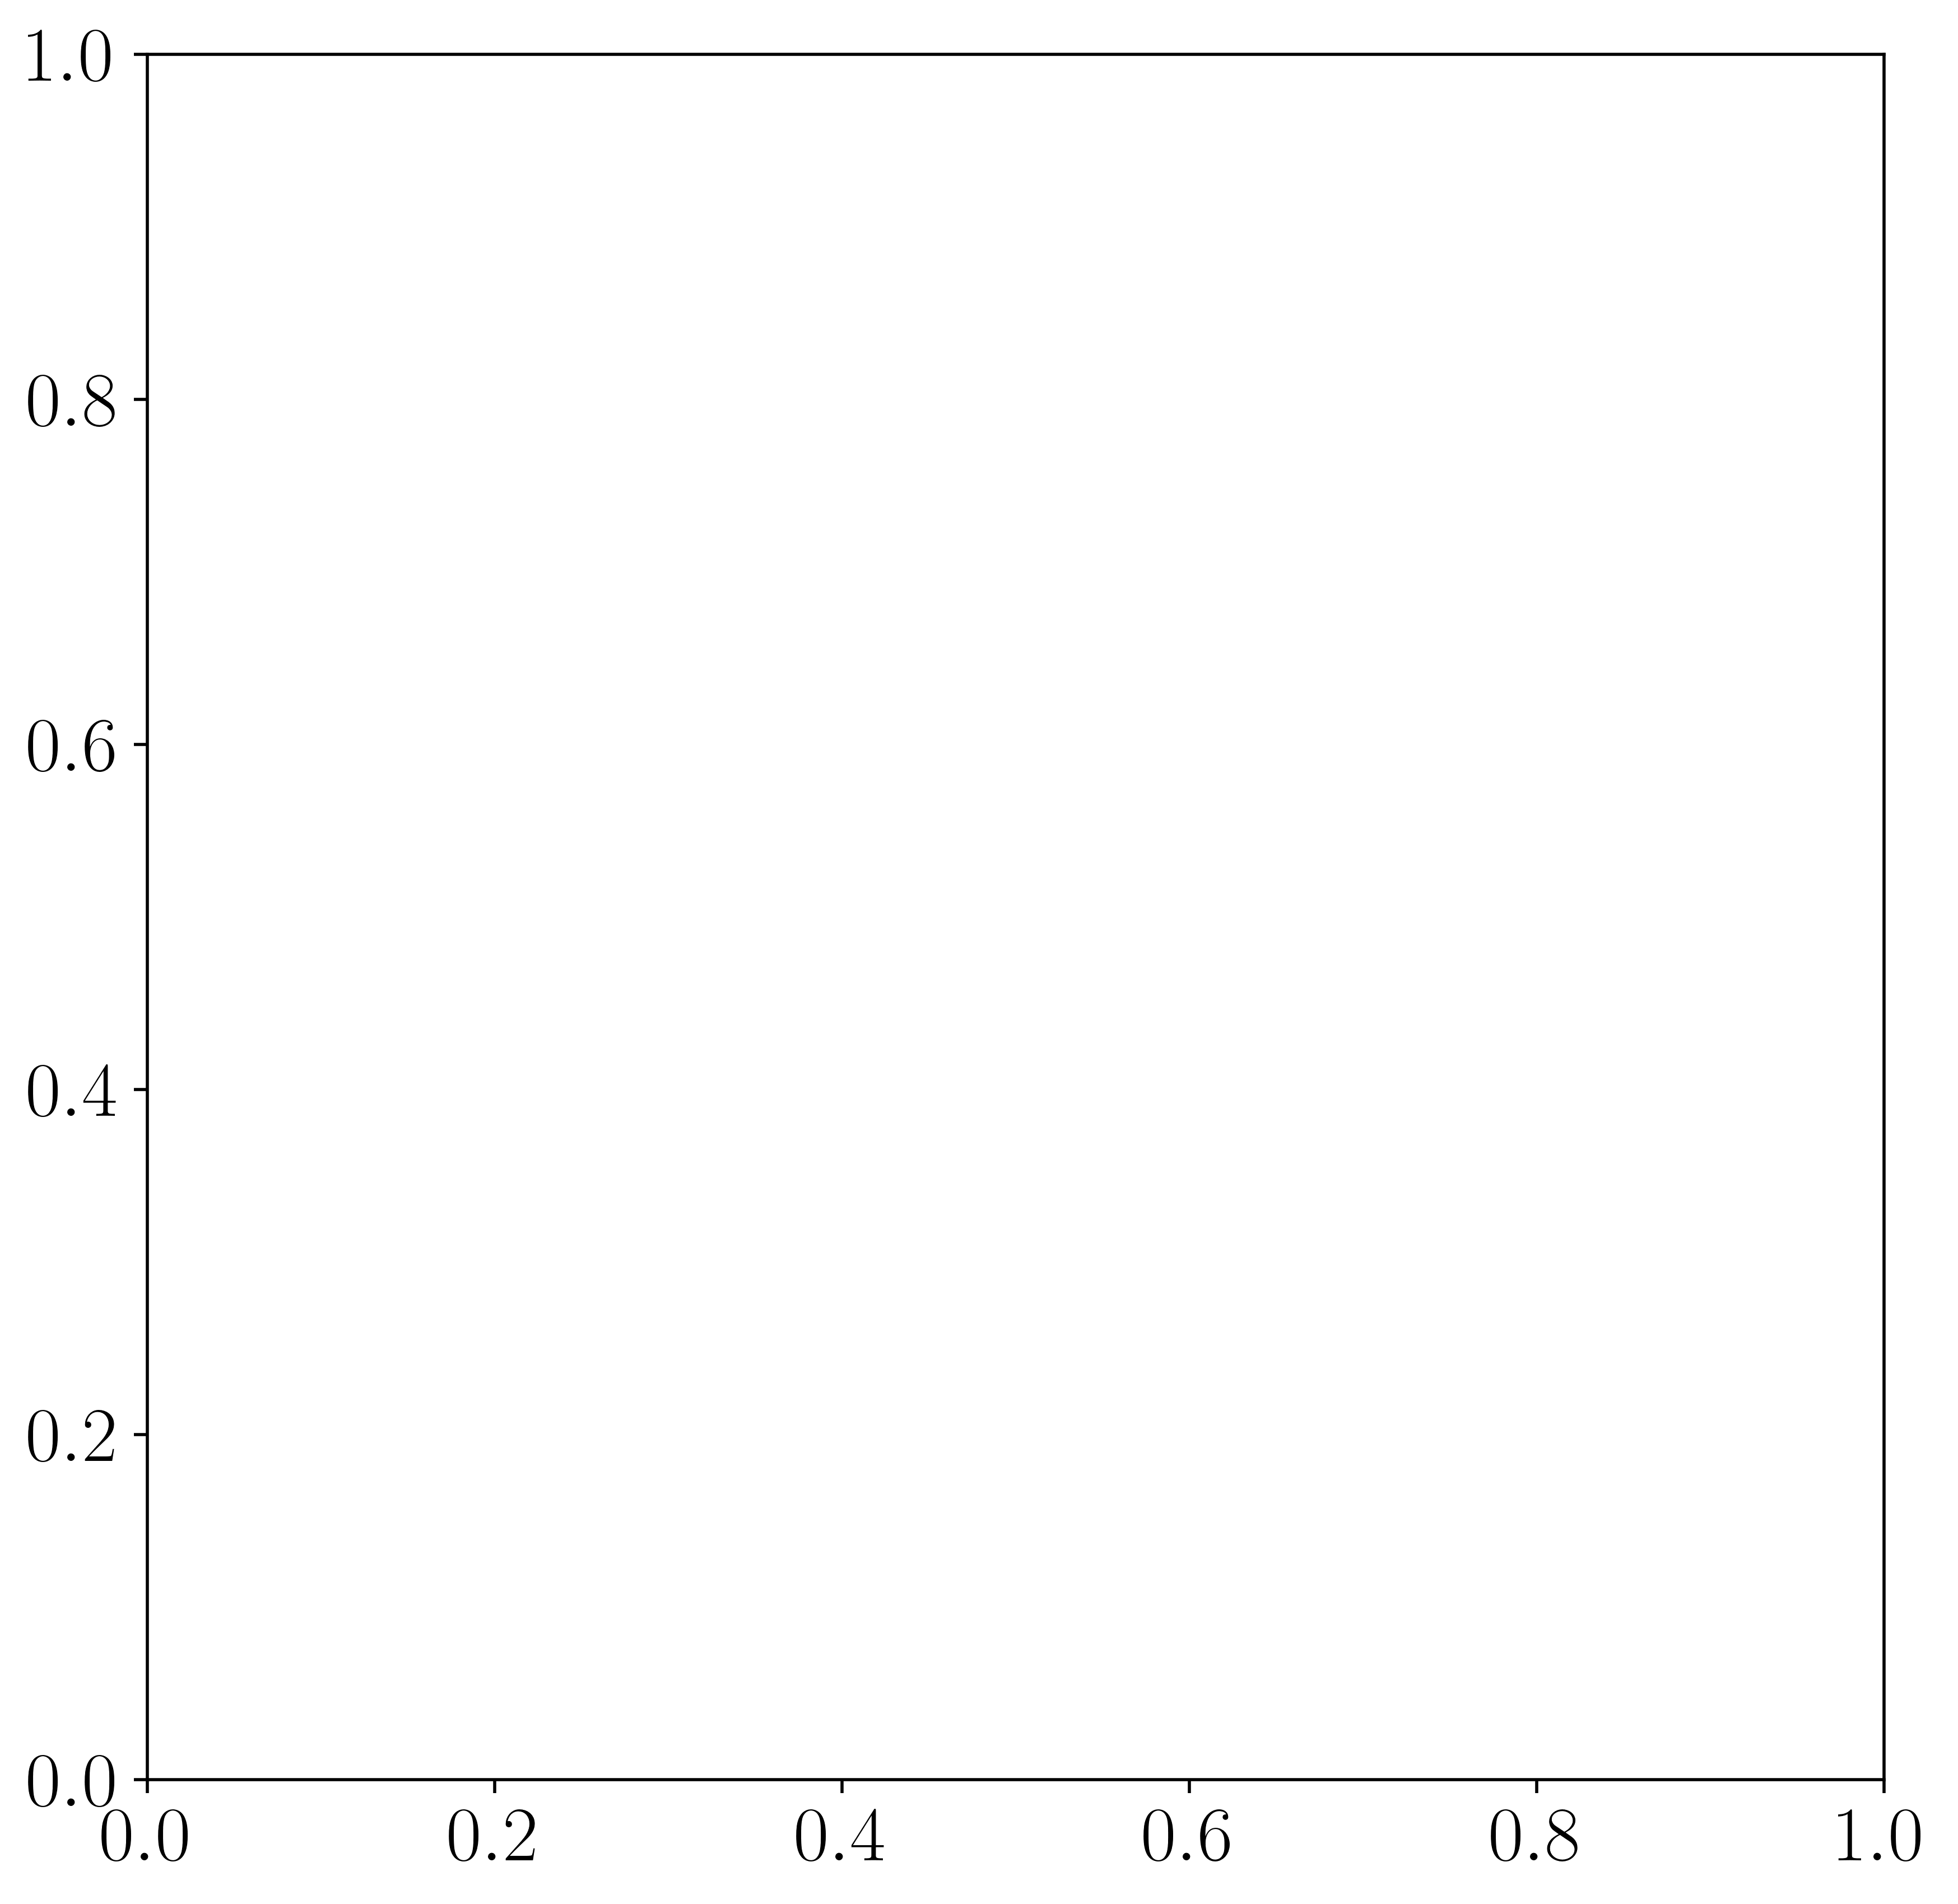

In [38]:

ind = np.arange(len(casenames))

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(ind,power, 'o-k', label='WRF')
ax.plot(ind,P, 'o-r', label='Offline')

# # ax.plot(veers,madsen[v_inds], 'o-b', label='Modified Madsen')
# ax.plot(veers_mit,madsen, 'o-b', label='Modified Madsen')


# ax.set_xticks(veers)

# ax.set_ylim([0.40, 0.60])
# ax.set_ylabel('$C_P$ [-]', fontsize=15)
# ax.set_xlabel('Veer rate [deg/m]', fontsize=15)

ax.legend()